In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import Dataset as HFDataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix
)

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    AutoTokenizer, AutoModelForSequenceClassification,
    LongformerTokenizer, LongformerForSequenceClassification,
    Trainer, TrainingArguments
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------
# Utility: softmax for logits -> probabilities
# -------------------
def logits_to_probs(logits):
    # logits: numpy array (N, C)
    probs = F.softmax(torch.from_numpy(logits), dim=1).numpy()
    return probs

# -------------------
# Data load
# -------------------
file_path = "bert_subtasks_labeled.csv"
df = pd.read_csv(file_path)
print("Raw dataframe shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Label distribution:\n", df["label"].value_counts())

df_bert = df.copy()
df_nli  = df.copy()
df_long = df.copy()

# =========================
# BERT preprocessing & training
# =========================

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
special_tokens = {
    "additional_special_tokens": [
        "[TASK_IDX]","[TEXT]","[DESCRIPTION]","[AGENT_NAME]","[RESPONSE]","[FINAL_ANSWER]"
    ]
}
bert_tokenizer.add_special_tokens(special_tokens)

MAX_RESP_TOKENS = 150
MAX_FINAL_TOKENS = 150

def smart_truncate(text, max_tokens, tokenizer=bert_tokenizer):
    if not isinstance(text, str):
        text = str(text)
    tokens = tokenizer.tokenize(text)
    if len(tokens) <= max_tokens:
        return text
    head_tokens = tokens[: max_tokens - 50]
    tail_tokens = tokens[-50:]
    head = tokenizer.convert_tokens_to_string(head_tokens)
    tail = tokenizer.convert_tokens_to_string(tail_tokens)
    return head + " ... " + tail

df_bert["response_k_trunc"] = df_bert["response_k"].apply(lambda x: smart_truncate(x, MAX_RESP_TOKENS))
df_bert["final_answer_k_trunc"] = df_bert["final_answer_k"].apply(lambda x: smart_truncate(x, MAX_FINAL_TOKENS))

def combine_fields(row):
    return (
        f"[TASK_IDX] {row['task_idx']} "
        f"[TEXT] {row['text']} "
        f"[DESCRIPTION] {row['description_k']} "
        f"[AGENT_NAME] {row['agent_name_k']} "
        f"[RESPONSE] {row['response_k_trunc']} "
        f"[FINAL_ANSWER] {row['final_answer_k_trunc']}"
    )

df_bert["combined_text"] = df_bert.apply(combine_fields, axis=1)
df_bert = df_bert[["combined_text", "label"]].dropna().copy()
df_bert["label"] = df_bert["label"].astype(int)

# Balance by undersampling negatives to match positives
n_pos = df_bert["label"].sum()
df_bert_0 = df_bert[df_bert["label"] == 0].sample(n=n_pos, random_state=42)
df_bert_1 = df_bert[df_bert["label"] == 1]
df_bert_bal = pd.concat([df_bert_0, df_bert_1], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

train_df_bert, test_df_bert = train_test_split(df_bert_bal, test_size=0.15, random_state=42, stratify=df_bert_bal["label"])
train_df_bert, val_df_bert  = train_test_split(train_df_bert, test_size=0.15, random_state=42, stratify=train_df_bert["label"])

def tokenize_bert_batch(batch):
    return bert_tokenizer(batch["combined_text"], truncation=True, padding="max_length", max_length=384)

hf_train_bert = HFDataset.from_pandas(train_df_bert).map(lambda b: tokenize_bert_batch(b), batched=True, remove_columns=train_df_bert.columns.tolist())
hf_val_bert   = HFDataset.from_pandas(val_df_bert).map(lambda b: tokenize_bert_batch(b), batched=True, remove_columns=val_df_bert.columns.tolist())
hf_test_bert  = HFDataset.from_pandas(test_df_bert).map(lambda b: tokenize_bert_batch(b), batched=True, remove_columns=test_df_bert.columns.tolist())

# attach labels and set format
hf_train_bert = hf_train_bert.add_column("labels", train_df_bert["label"].to_list())
hf_val_bert   = hf_val_bert.add_column("labels", val_df_bert["label"].to_list())
hf_test_bert  = hf_test_bert.add_column("labels", test_df_bert["label"].to_list())

hf_train_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
hf_val_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
hf_test_bert.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Model init
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)
bert_model.resize_token_embeddings(len(bert_tokenizer))

# compute_metrics for Trainer (BERT)
def compute_metrics_binary_auc(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = logits_to_probs(logits)  # numpy (N,2)
    probs_pos = probs[:, 1]          # positive class prob

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "auc": float(roc_auc_score(labels, probs_pos)) if len(np.unique(labels)) > 1 else float("nan")
    }

# TrainingArgs
bert_args = TrainingArguments(
    output_dir="./bert_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=hf_train_bert,
    eval_dataset=hf_val_bert,
    tokenizer=bert_tokenizer,
    compute_metrics=compute_metrics_binary_auc
)

print("Starting BERT training...")
bert_trainer.train()
print("BERT training done.")
bert_eval = bert_trainer.evaluate(hf_test_bert)
print("BERT test eval:", bert_eval)

# get test probs for ROC plotting
bert_preds_out = bert_trainer.predict(hf_test_bert)  # Predictions object
bert_logits = bert_preds_out.predictions
bert_probs = logits_to_probs(bert_logits)[:, 1]
bert_labels = bert_preds_out.label_ids

# =========================
# NLI RoBERTa (baseline + finetune)
# =========================

# Prepare premise/hypothesis pairs (trajectory-level build function)
def build_trajectory(df_in):
    df_n = df_in.copy()
    df_n['uid'] = df_n['uid'].astype(str).str.strip()
    df_n['task_idx'] = df_n['task_idx'].astype(int)
    df_n['description_k'] = df_n['description_k'].fillna("").astype(str)
    df_n['final_answer_k'] = df_n['final_answer_k'].fillna("").astype(str)
    df_n['text'] = df_n['text'].fillna("").astype(str)
    df_n['label'] = df_n['label'].fillna(0).astype(int)

    rows = []
    for uid, group in df_n.groupby('uid'):
        g = group.sort_values('task_idx')
        subtasks = [f"[Subtask {int(r['task_idx'])}] {r['description_k']} -> {r['final_answer_k']}" for _, r in g.iterrows()]
        premise = f"question: {g['text'].iloc[0]}\nall subtasks:\n" + "\n".join(subtasks)
        traj_label = int(g['label'].max())
        rows.append({"uid": uid, "premise": premise, "label_binary": traj_label})
    return pd.DataFrame(rows)

traj_df = build_trajectory(df_nli)
traj_df["hypothesis"] = "This trajectory contains a hallucination."
traj_df["nli_label"] = traj_df["label_binary"].apply(lambda x: 1 if x == 1 else 0)

train_df_nli, test_df_nli = train_test_split(traj_df, test_size=0.15, stratify=traj_df["label_binary"], random_state=42)
train_df_nli, val_df_nli  = train_test_split(train_df_nli, test_size=0.15, stratify=train_df_nli["label_binary"], random_state=42)

# Baseline NLI evaluation (no fine-tuning): use AutoTokenizer/AutoModel and get entailment probs
nli_baseline_tokenizer = AutoTokenizer.from_pretrained("cross-encoder/nli-roberta-base")
nli_baseline_model = AutoModelForSequenceClassification.from_pretrained("cross-encoder/nli-roberta-base").to(device)
nli_baseline_model.eval()

def nli_predict_probs_entailment(premises, hypotheses, batch_size=16):
    # returns prob(entailment) for each pair (index = 1)
    probs_list = []
    for i in range(0, len(premises), batch_size):
        batch_p = premises[i:i+batch_size]
        batch_h = hypotheses[i:i+batch_size]
        enc = nli_baseline_tokenizer(batch_p, batch_h, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            out = nli_baseline_model(**enc)
            logits = out.logits.cpu().numpy()
            probs = logits_to_probs(logits)
            probs_list.extend(probs[:, 1].tolist())  # entailment column = 1
    return np.array(probs_list)

# Baseline predictions and metrics
nli_test_entail_probs = nli_predict_probs_entailment(test_df_nli["premise"].tolist(), test_df_nli["hypothesis"].tolist())
nli_test_labels = test_df_nli["label_binary"].values
# thresholding: predict 1 if entailment prob >= 0.5 (same as argmax mapping to entailment)
nli_test_preds = (nli_test_entail_probs >= 0.5).astype(int)

print("NLI baseline accuracy:", accuracy_score(nli_test_labels, nli_test_preds))
print("NLI baseline f1:", f1_score(nli_test_labels, nli_test_preds))
print("NLI baseline auc (entailment prob):", roc_auc_score(nli_test_labels, nli_test_entail_probs))

# Fine-tune the NLI model (3-class head kept)
nli_tokenizer = nli_baseline_tokenizer
# Prepare HF datasets for fine-tuning
def tokenize_nli_batch(batch):
    return nli_tokenizer(batch["premise"], batch["hypothesis"], truncation=True, padding="max_length", max_length=512)

hf_train_nli = HFDataset.from_pandas(train_df_nli[["premise","hypothesis","nli_label"]].rename(columns={"nli_label":"labels"})).map(lambda b: tokenize_nli_batch(b), batched=True, remove_columns=["premise","hypothesis","labels"])
hf_val_nli   = HFDataset.from_pandas(val_df_nli[["premise","hypothesis","nli_label"]].rename(columns={"nli_label":"labels"})).map(lambda b: tokenize_nli_batch(b), batched=True, remove_columns=["premise","hypothesis","labels"])
hf_test_nli  = HFDataset.from_pandas(test_df_nli[["premise","hypothesis","nli_label"]].rename(columns={"nli_label":"labels"})).map(lambda b: tokenize_nli_batch(b), batched=True, remove_columns=["premise","hypothesis","labels"])

# add "labels" column back from original frames (HFDataset.from_pandas drop handling)
hf_train_nli = hf_train_nli.add_column("labels", train_df_nli["nli_label"].to_list())
hf_val_nli   = hf_val_nli.add_column("labels", val_df_nli["nli_label"].to_list())
hf_test_nli  = hf_test_nli.add_column("labels", test_df_nli["nli_label"].to_list())

hf_train_nli.set_format(type="torch")
hf_val_nli.set_format(type="torch")
hf_test_nli.set_format(type="torch")

# model for finetuning (keep 3 labels)
nli_finetune_model = AutoModelForSequenceClassification.from_pretrained("cross-encoder/nli-roberta-base", num_labels=3).to(device)

def compute_metrics_nli(eval_pred):
    logits, labels = eval_pred  # labels are nli_label (0/1)
    preds = np.argmax(logits, axis=1)  # 0/1/2
    # convert to binary: entailment (index=1) -> hallucination(1), else 0
    binary_preds = (preds == 1).astype(int)
    binary_labels = (labels == 1).astype(int)
    # For AUC: use probability of entailment (index=1)
    probs = logits_to_probs(logits)
    probs_entail = probs[:, 1]
    auc_val = float(roc_auc_score(binary_labels, probs_entail)) if len(np.unique(binary_labels)) > 1 else float("nan")
    return {
        "accuracy": accuracy_score(binary_labels, binary_preds),
        "f1": f1_score(binary_labels, binary_preds, zero_division=0),
        "precision": precision_score(binary_labels, binary_preds, zero_division=0),
        "recall": recall_score(binary_labels, binary_preds, zero_division=0),
        "auc": auc_val
    }

nli_args = TrainingArguments(
    output_dir="./nli_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    metric_for_best_model="f1",
    report_to="none"
)

nli_trainer = Trainer(
    model=nli_finetune_model,
    args=nli_args,
    train_dataset=hf_train_nli,
    eval_dataset=hf_val_nli,
    tokenizer=nli_tokenizer,
    compute_metrics=compute_metrics_nli
)

print("Starting NLI fine-tuning...")
nli_trainer.train()
print("NLI fine-tuning finished.")
nli_eval = nli_trainer.evaluate(hf_test_nli)
print("NLI test eval (finetuned):", nli_eval)

# get test probs (entailment) for plotting
nli_preds_out = nli_trainer.predict(hf_test_nli)
nli_logits_test = nli_preds_out.predictions
nli_probs_test = logits_to_probs(nli_logits_test)[:, 1]  # entailment prob
nli_labels_test = nli_preds_out.label_ids



Device: cuda
Raw dataframe shape: (1245, 9)
Columns: ['uid', 'task_idx', 'text', 'description_k', 'agent_name_k', 'response_k', 'final_answer_k', 'label', 'type']
Label distribution:
 label
0    1004
1     241
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

/tmp/ipython-input-290764386.py:290: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  nli_trainer = Trainer(


Starting NLI fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,No log,0.786576,0.448276,0.529412,0.409091,0.750000,0.441176
2,No log,0.785274,0.482759,0.347826,0.363636,0.333333,0.411765
3,0.761600,0.804778,0.448276,0.200000,0.250000,0.166667,0.426471


NLI fine-tuning finished.


NLI test eval (finetuned): {'eval_loss': 0.6812787055969238, 'eval_accuracy': 0.5882352941176471, 'eval_f1': 0.5625, 'eval_precision': 0.5, 'eval_recall': 0.6428571428571429, 'eval_auc': 0.6892857142857143, 'eval_runtime': 1.0286, 'eval_samples_per_second': 33.054, 'eval_steps_per_second': 4.861, 'epoch': 3.0}


In [2]:
# =========================
# Longformer (trajectory-level)
# =========================

# Build trajectories
traj_df_long = build_trajectory(df_long)

# Undersample majority class
minority_count = traj_df_long["label_binary"].value_counts()[1]
df0 = traj_df_long[traj_df_long["label_binary"] == 0].sample(n=minority_count, random_state=42)
df1 = traj_df_long[traj_df_long["label_binary"] == 1]

traj_df_long_bal = (
    pd.concat([df0, df1])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Train/val/test split
train_df_long, test_df_long = train_test_split(
    traj_df_long_bal,
    test_size=0.15,
    stratify=traj_df_long_bal["label_binary"],
    random_state=42
)
train_df_long, val_df_long = train_test_split(
    train_df_long,
    test_size=0.15,
    stratify=train_df_long["label_binary"],
    random_state=42
)

# Tokenizer
long_tokenizer = LongformerTokenizer.from_pretrained("allenai/longformer-base-4096")

def tokenize_long_batch(batch):
    return long_tokenizer(
        batch["premise"],
        truncation=True,
        padding="max_length",
        max_length=4096
    )

# HF datasets
hf_train_long = (
    HFDataset.from_pandas(
        train_df_long[["premise", "label_binary"]].rename(columns={"label_binary": "labels"})
    )
    .map(tokenize_long_batch, batched=True)
    .remove_columns(["premise"])
)
hf_val_long = (
    HFDataset.from_pandas(
        val_df_long[["premise", "label_binary"]].rename(columns={"label_binary": "labels"})
    )
    .map(tokenize_long_batch, batched=True)
    .remove_columns(["premise"])
)
hf_test_long = (
    HFDataset.from_pandas(
        test_df_long[["premise", "label_binary"]].rename(columns={"label_binary": "labels"})
    )
    .map(tokenize_long_batch, batched=True)
    .remove_columns(["premise"])
)

hf_train_long.set_format(type="torch")
hf_val_long.set_format(type="torch")
hf_test_long.set_format(type="torch")

# ----------------------------
# Baseline Longformer
# ----------------------------
baseline_long = LongformerForSequenceClassification.from_pretrained(
    "allenai/longformer-base-4096",
    num_labels=2
).to(device)
baseline_long.eval()

def baseline_long_probs(dataset, batch_size=1):
    labels_all, preds_all, probs_all = [], [], []
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)

    for batch in loader:
        inputs = {
            k: v.to(device)
            for k, v in batch.items()
            if k in ["input_ids", "attention_mask"]
        }

        with torch.no_grad():
            out = baseline_long(**inputs)
            logits = out.logits.cpu().numpy()
            batch_probs = logits_to_probs(logits)[:, 1]
            batch_preds = (batch_probs >= 0.5).astype(int)

        labels_all.extend(batch["labels"].numpy().tolist())
        preds_all.extend(batch_preds.tolist())
        probs_all.extend(batch_probs.tolist())

    return np.array(labels_all), np.array(preds_all), np.array(probs_all)


# Run baseline
long_bas_labels, long_bas_preds, long_bas_probs = baseline_long_probs(hf_test_long)

print("Longformer baseline acc/f1:",
      accuracy_score(long_bas_labels, long_bas_preds),
      f1_score(long_bas_labels, long_bas_preds))

if len(np.unique(long_bas_labels)) > 1:
    print("Longformer baseline auc:", roc_auc_score(long_bas_labels, long_bas_probs))


# ----------------------------
# Fine-tuning Longformer
# ----------------------------
long_model = LongformerForSequenceClassification.from_pretrained(
    "allenai/longformer-base-4096",
    num_labels=2
).to(device)

def compute_metrics_long(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = logits_to_probs(logits)[:, 1]

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "auc": float(roc_auc_score(labels, probs)) if len(np.unique(labels)) > 1 else float("nan")
    }

long_args = TrainingArguments(
    output_dir="./long_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    num_train_epochs=3,
    load_best_model_at_end=True,
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

long_trainer = Trainer(
    model=long_model,
    args=long_args,
    train_dataset=hf_train_long,
    eval_dataset=hf_val_long,
    compute_metrics=compute_metrics_long
)

print("Starting Longformer fine-tuning...")
long_trainer.train()
print("Longformer fine-tuning done.")

long_eval = long_trainer.evaluate(hf_test_long)
print("Longformer test eval (finetuned):", long_eval)

# Test predictions
long_preds_out = long_trainer.predict(hf_test_long)
long_logits_test = long_preds_out.predictions
long_probs_test = logits_to_probs(long_logits_test)[:, 1]
long_labels_test = long_preds_out.label_ids


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Map:   0%|          | 0/130 [00:00<?, ? examples/s]

...

Some weights of LongformerForSequenceClassification were not initialized from the model checkpoint at allenai/longformer-base-4096 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting Longformer fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Auc
1,0.680000,0.707923,0.521739,0.685714,0.521739,1.000000,0.477273
2,0.710100,0.706798,0.434783,0.551724,0.470588,0.666667,0.507576
3,0.700900,0.711256,0.521739,0.521739,0.545455,0.500000,0.530303


Longformer fine-tuning done.


Longformer test eval (finetuned): {'eval_loss': 0.6856192350387573, 'eval_accuracy': 0.48148148148148145, 'eval_f1': 0.5333333333333333, 'eval_precision': 0.47058823529411764, 'eval_recall': 0.6153846153846154, 'eval_auc': 0.5989010989010989, 'eval_runtime': 5.4501, 'eval_samples_per_second': 4.954, 'eval_steps_per_second': 4.954, 'epoch': 3.0}


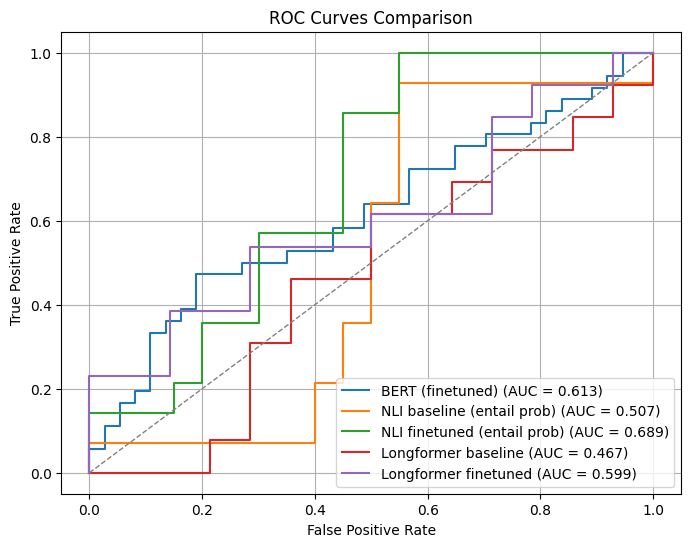

In [3]:
# =========================
# Plotting ROC curves for all models
# =========================
def plot_roc_curves(curve_dict):
    """
    curve_dict: dict[name] = (y_true_array, y_score_array)
    """
    plt.figure(figsize=(8,6))
    for name, (y_true, y_score) in curve_dict.items():
        # If only one class present, skip plotting ROC
        if len(np.unique(y_true)) < 2:
            print(f"Skipping ROC for {name} (only one label present).")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves Comparison")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Prepare dictionary of curves using test sets
curves = {
    "BERT (finetuned)": (bert_labels, bert_probs),
    "NLI baseline (entail prob)": (nli_test_labels, nli_test_entail_probs),
    "NLI finetuned (entail prob)": (nli_labels_test, nli_probs_test),
    "Longformer baseline": (long_bas_labels, long_bas_probs),
    "Longformer finetuned": (long_labels_test, long_probs_test)
}

plot_roc_curves(curves)
